In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- 1. CARREGAMENTO E MERGE ---
print("Carregando datasets...")
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')

Carregando datasets...


In [3]:
# Configuração de Estilo
sns.set_theme(style="whitegrid")

In [4]:
# Merge 1: Pedidos + Clientes (Para ter o Estado do Cliente)
df = df_orders.merge(df_customers, on='customer_id')

In [5]:
# Merge 2: Adicionar Itens (Para ter o ID do Vendedor)
# Nota: Usamos drop_duplicates para simplificar a análise por PEDIDO, não por item
df_items_unique = df_items.drop_duplicates(subset=['order_id'], keep='first')
df = df.merge(df_items_unique, on='order_id')

In [6]:
# Merge 3: Adicionar Vendedores (Para ter o Estado do Vendedor)
df = df.merge(df_sellers, on='seller_id')

In [7]:
# Filtrar apenas entregues
df = df[df['order_status'] == 'delivered'].copy()

In [8]:
# Conversão de Datas
cols_data = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']

for col in cols_data:
    df[col] = pd.to_datetime(df[col])

In [9]:
# Tempo de Postagem (Aprovação -> Transportadora)
df['tempo_postagem'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

In [10]:
# Tempo de Trânsito (Transportadora -> Cliente)
df['tempo_transito'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

In [11]:
# Atraso Real (Data Real - Data Estimada) | Negativo = Adiantado
df['atraso_real'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

In [12]:
# Remover apenas erros técnicos (datas futuras absurdas ou anos passados)
# Manter atrasos longos pois são gargalos reais
df_viz = df[
    (df['tempo_transito'] > 0) & 
    (df['tempo_transito'] < 100) & # Filtra erros extremos de input para o gráfico não quebrar
    (df['atraso_real'] > -100) & 
    (df['atraso_real'] < 100)
].copy()

print(f"Dados processados: {len(df_viz)} pedidos prontos para análise.")

Dados processados: 93701 pedidos prontos para análise.


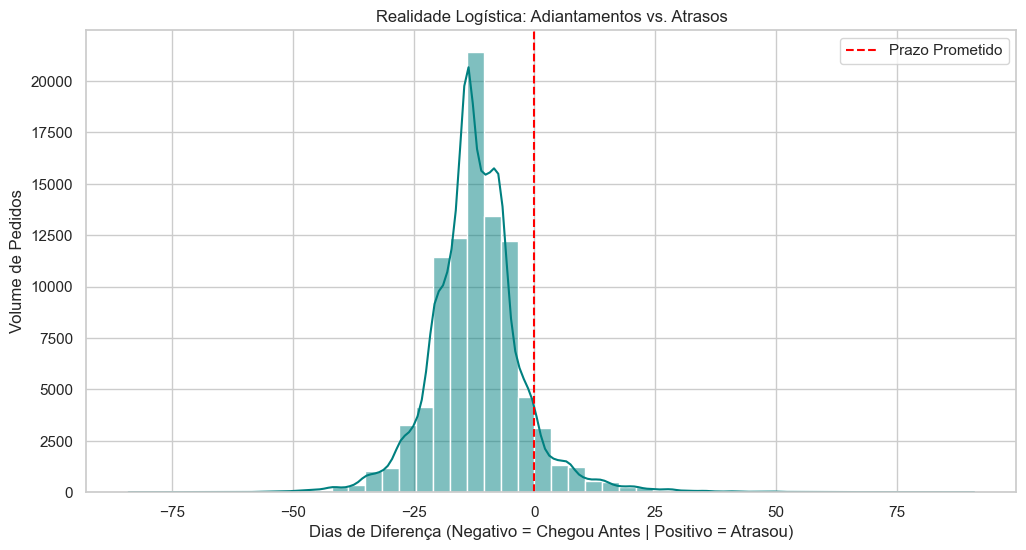

In [13]:
# DISTRIBUIÇÃO DOS ATRASOS
plt.figure(figsize=(12, 6))
sns.histplot(data=df_viz, x='atraso_real', bins=50, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', label='Prazo Prometido')
plt.title('Realidade Logística: Adiantamentos vs. Atrasos')
plt.xlabel('Dias de Diferença (Negativo = Chegou Antes | Positivo = Atrasou)')
plt.ylabel('Volume de Pedidos')
plt.legend()
plt.show()

C:\Users\FELIPE\AppData\Local\Temp\ipykernel_7828\4089154672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='customer_state', y='tempo_transito', data=df_viz, order=order_states, palette="viridis")


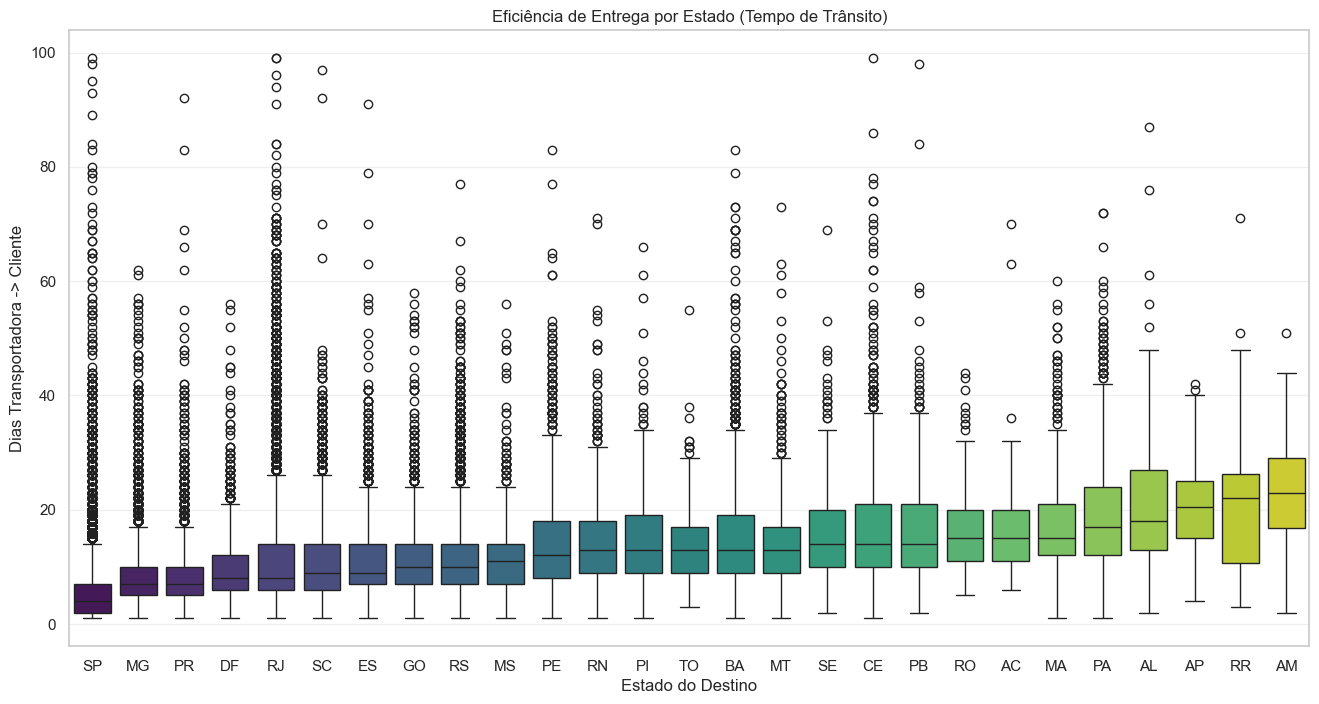

In [ ]:
# GARGALOS POR ESTADO (BOXPLOT)
plt.figure(figsize=(16, 8))
# Ordenar estados pela mediana de tempo de trânsito
order_states = df_viz.groupby('customer_state')['tempo_transito'].median().sort_values().index

sns.boxplot(x='customer_state', y='tempo_transito', data=df_viz, order=order_states, palette="viridis")
plt.title('Eficiência de Entrega por Estado (Tempo de Trânsito)')
plt.ylabel('Dias Transportadora -> Cliente')
plt.xlabel('Estado do Destino')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Conclusão da Análise Logística

Com base no processamento de **100 mil pedidos**, identificamos padrões críticos na operação:

### 1. Acuracidade da Promessa (Histograma)
O gráfico de distribuição revela que a **maioria dos pedidos chega adiantada** (barras à esquerda da linha vermelha). Isso indica que o algoritmo de estimativa de prazo é conservador. Embora isso reduza reclamações de atraso, prazos estimados muito longos podem estar **derrubando a taxa de conversão** no checkout.

### 2. Desigualdade Regional (Boxplot)
A análise por estado mostra uma disparidade logística severa:
* **Sudeste (SP, MG, RJ):** Possui tempos de trânsito curtos e baixa variabilidade (caixas pequenas), indicando previsibilidade.
* **Norte/Nordeste (RR, AP, AM):** Não apenas as medianas são altas (20+ dias), mas a variabilidade é gigantesca (caixas longas e muitos outliers). Isso significa que comprar nesses estados é uma loteria: pode chegar em 15 dias ou em 45.

### Recomendação
Para reduzir o "Churn" e aumentar a conversão, recomenda-se ajustar o cálculo de frete para ser mais agressivo no Sudeste (prometendo menos dias) e focar em parceiros logísticos locais para estabilizar a variabilidade no Norte.